In [ ]:
import scib

import warnings
warnings.filterwarnings("ignore")

### 定义一些函数

In [2]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from tqdm import trange
from scipy.spatial import *
from sklearn.preprocessing import *

from sklearn.metrics import *
from scipy.spatial.distance import *

"""
SCS
PAS
CHAOS
ASW
"""

def _get_spatial_entropy(C, C_sum):
    H = 0
    for i in range(len(C)):
        for j in range(len(C)):
            z = C[i, j]
            if z != 0:
                H += -(z / C_sum) * np.log(z / C_sum)
    return H

# def spatial_entropy(g, labels):
def spatial_entropy(k_neighbors, labels, degree=4):
    """
    Calculates spatial entropy of graph
    """
    # construct contiguity matrix C which counts pairs of cluster edges
    # nx.set_node_attributes(g, labels, "labels")
    # cluster_nums = len(np.unique(list(labels.values())))
    # C = np.zeros((cluster_nums, cluster_nums))
    # for e in g.edges():
    #     C[labels[e[0]]][labels[e[1]]] += 1


    # S = np.repeat(adata.obs[annotation_key].values[:, None], degree, axis=1)
    S = np.broadcast_to(labels[:, None], (len(labels), degree))
    N = labels[k_neighbors]
    cluster_names = np.unique(labels)
    cluster_nums = len(cluster_names)
    C = np.zeros((cluster_nums, cluster_nums))
    for i in range(cluster_nums):
        for j in range(cluster_nums):
            # C[i, j] = np.sum(np.logical_and(N == i, S == j))
            C[i, j] = np.sum(np.logical_and(S == cluster_names[i], N == cluster_names[j]))
    # cluster_names = np.unique(list(labels.values()))
    # C = pd.DataFrame(0,index=cluster_names, columns=cluster_names)
    # C = np.zeros((len(cluster_names), len(cluster_names)))

    # calculate entropy from C
    # C_sum = C.values.sum()
    C_sum = C.sum()
    # print("C_sum", C_sum)
    # H = 0
    # # for i in range(len(cluster_names)):
    # #     for j in range(i, len(cluster_names)):
    # #         if (i == j):
    # #             z = C[cluster_names[i]][cluster_names[j]]
    # #         else:
    # #             z = C[cluster_names[i]][cluster_names[j]] + C[cluster_names[j]][cluster_names[i]]
    # #         if z != 0:
    # #             H += -(z/C_sum)*math.log(z/C_sum)
    # for i in range(len(C)):
    #     for j in range(len(C)):
    #         z = C[i, j]
    #         if z != 0:
    #             H += -(z / C_sum) * np.log(z / C_sum)
    # return H
    return _get_spatial_entropy(C, C_sum)

def sigmoid_score(raw_score):
    return 1 / (1 + np.exp(-raw_score))

def spatial_coherence_score(adata, annotation_key, degree=4, rep_time=1000, seed=0):
    spatial_coords = adata.obsm['spatial']
    origin_labels = adata.obs[annotation_key].values
    # Use kneighbors_graph to get the adjacency matrix
    neigh = NearestNeighbors(n_neighbors=degree, metric='euclidean').fit(spatial_coords)
    # adjacency_matrix = neigh.kneighbors_graph(n_neighbors=degree, mode='connectivity').toarray().astype(np.int32)
    k_neighbors = neigh.kneighbors(n_neighbors=degree, return_distance=False)
    true_entropy = spatial_entropy(k_neighbors, origin_labels, degree=degree)
    entropies = []
    rng = np.random.default_rng(seed)
    shuffled_labels = origin_labels.copy()
    # for _ in trange(1000):
    for _ in trange(rep_time):
        rng.shuffle(shuffled_labels)
        entropies.append(spatial_entropy(k_neighbors, shuffled_labels, degree=degree))

    raw_score = (true_entropy - np.mean(entropies)) / np.std(entropies)
    normalized_score = sigmoid_score(raw_score)

    return normalized_score, true_entropy, entropies


def CHAOS_score(X, pred_labels):
    """
    Calculate the CHAOS score for a given set of spatial coordinates and predicted labels.

    param: X - spatial coordinates
    param: pred_labels - predicted labels

    return: CHAOS score
    """
    # Standardize the spatial coordinates
    X = StandardScaler().fit_transform(X)

    # Get the unique cluster labels
    cluster_labels = np.unique(pred_labels)

    # Initialize the distance value and count
    dist_val = 0.
    count = 0

    # Iterate through each cluster
    for k in cluster_labels:
        # Get the spatial coordinates for the current cluster
        cluster_coords = X[pred_labels == k, :]

        # Check if there are at least 2 spatial coordinates in the cluster
        if len(cluster_coords) <= 2:
            continue
        else:
            count += len(cluster_coords)

        # Calculate the distance to the nearest neighbor for each spatial coordinate in the cluster
        nbrs = NearestNeighbors(n_neighbors=1).fit(cluster_coords)
        distances, _ = nbrs.kneighbors()

        # Sum the distances
        dist_val = dist_val + np.sum(distances)

    # Calculate the CHAOS score
    return dist_val / count


def PAS_score(X, pred_labels, k=6):
    """
    Calculate the PAS score for a given set of spatial coordinates and predicted labels.

    param: X - spatial coordinates
    param: pred_labels - predicted labels
    param: k - number of nearest neighbors to consider

    return: PAS score
    """
    # Use NearestNeighbors to find the nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    indices = nbrs.kneighbors(return_distance=False)
    # print("type(indices)", type(indices))
    # print("type(pred_labels)", type(pred_labels))
    # print("indices.shape", indices.shape)
    # print("pred_labels.shape", pred_labels.shape)
    # Calculate the PAS score
    return ((pred_labels.reshape(-1, 1) != pred_labels[indices]).sum(1) > k / 2).mean()

In [3]:
import os
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def pca(adata, use_reps=None, n_comps=10):

    """Dimension reduction with PCA algorithm"""

    from sklearn.decomposition import PCA
    from scipy.sparse.csc import csc_matrix
    from scipy.sparse.csr import csr_matrix
    pca = PCA(n_components=n_comps)
    if use_reps is not None:
       feat_pca = pca.fit_transform(adata.obsm[use_reps])
    else:
       if isinstance(adata.X, csc_matrix) or isinstance(adata.X, csr_matrix):
          feat_pca = pca.fit_transform(adata.X.toarray())
       else:
          feat_pca = pca.fit_transform(adata.X)

    return feat_pca

def supervised_clustering(adata, n_clusters=7, key='Garfield', add_key='Garfield_cluster', cluster_method='leiden',
               start=0.5, end=2.0, increment=0.05, use_pca=False, n_comps=20):
    if use_pca:
       adata.obsm[key + '_pca'] = pca(adata, use_reps=key, n_comps=n_comps)

    method_cluster = add_key
    method = key
    
    if cluster_method == 'leiden':
       if use_pca:
          res = search_res(adata, n_clusters, use_rep=key + '_pca', cluster_method=cluster_method, 
                           start=start, end=end, increment=increment)
       else:
          res = search_res(adata, n_clusters, use_rep=method, cluster_method=cluster_method, 
                           start=start, end=end, increment=increment)
       sc.tl.leiden(adata, random_state=0, key_added=method_cluster, resolution=res, neighbors_key=method)
    elif cluster_method == 'louvain':
       if use_pca:
          res = search_res(adata, n_clusters, use_rep=key + '_pca', cluster_method=cluster_method, 
                           start=start, end=end, increment=increment)
       else:
          res = search_res(adata, n_clusters, use_rep=method, cluster_method=cluster_method, 
                           start=start, end=end, increment=increment)
       sc.tl.louvain(adata, random_state=0, key_added=method_cluster, resolution=res, neighbors_key=method)

def search_res(adata, n_clusters, use_rep='Garfield', cluster_method='leiden', start=0.5, end=2.0,
               increment=0.05, expansion_factor=1.75, max_iter=50):
    '''\
    Searching corresponding resolution according to given cluster number

    Parameters
    ----------
    adata : anndata
        AnnData object of spatial data.
    n_clusters : int
        Target number of clusters.
    method : string
        Tool for clustering. Supported tools include 'leiden' and 'louvain'. The default is 'leiden'.
    use_rep : string
        The indicated representation for clustering.
    start : float
        The start value for searching.
    end : float
        The end value for searching.
    increment : float
        The step size to increase.
    expansion_factor : float
        Factor to expand the search range if no resolution is found in the initial range.
    max_iter : int
        Maximum number of iterations to prevent infinite loops.

    Returns
    -------
    res : float
        Resolution.

    '''
    print('Searching resolution...')
    label = 0
    method = use_rep
    method_cluster = method + '_cluster'
    
    current_start, current_end = start, end
    best_res = None
    best_diff = float('inf')  # Track the best resolution so far
    best_count = 0
    iteration = 0  # Track number of iterations
    
    # 构图
    sc.pp.neighbors(adata, use_rep=use_rep, key_added=method)

    while label == 0 and iteration < max_iter:
        iteration += 1
        for res in sorted(list(np.arange(current_start, current_end, increment)), reverse=True):
            if cluster_method == 'leiden':
                sc.tl.leiden(adata, random_state=0, key_added=method_cluster,
                             resolution=res, neighbors_key=method)
                count_unique = adata.obs[method_cluster].nunique()
            elif cluster_method == 'louvain':
                sc.tl.louvain(adata,  random_state=0, key_added=method_cluster, 
                             resolution=res, neighbors_key=method)
                count_unique = adata.obs[method_cluster].nunique()

            print(f'resolution={res}, cluster number={count_unique}')

            # Update the best resolution if it's closer to the target
            diff = abs(count_unique - n_clusters)
            if diff < best_diff:
                best_diff = diff
                best_res = res
                best_count = count_unique

            if count_unique == n_clusters:
                label = 1
                break

        if label == 0:
            if best_res is not None:
                # Instead of starting from scratch, continue from the closest found resolution
                if best_count > n_clusters:
                    current_start = min(best_res, current_start * 0.9)  # Avoid too small a search range
                    current_end = min(current_start * expansion_factor, end * 2)  # Limit max range
                    print(f"Expanding search range: new range ({current_start}, {current_end})")
                else:
                    current_start = max(best_res, current_start * 1.2)  # Avoid too small a search range
                    current_end = min(current_start * expansion_factor, end * 2)  # Limit max range
                    print(f"Expanding search range: new range ({current_start}, {current_end})")
            else:
                print("Warning: No valid resolution found yet, expanding the search range.")
                current_start *= expansion_factor
                current_end *= expansion_factor

    if iteration >= max_iter:
        print("Warning: Reached maximum iteration limit.")

    return best_res if label == 1 else None

In [32]:
import scanpy as sc
from sklearn.neighbors import kneighbors_graph
from pandas import get_dummies

def moranI_score(adata, key):
    g = kneighbors_graph(adata.obsm['spatial'], 6, mode='connectivity', metric='euclidean')
    one_hot = get_dummies(adata.obs[key])
    moranI = sc.metrics.morans_i(g, one_hot.values.T).mean()
    return moranI

In [83]:

dataset = 'mouse_brain'
res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/{dataset}'
sc.read_h5ad(f'{res_dir}/adata_Garfield.h5ad')

In [33]:
from sklearn import metrics
import scipy.sparse as sp

def count_metrics_for_resolution(dataset, reso_dict=None, adata_new=None, n_start_run=1,
                                 niche_type_key=None,
                                 n_end_run=8, n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16],
                                 start=0.5, end=2.0, increment=0.05):
    res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/{dataset}'

    result = pd.DataFrame()
    metrics_list = []
    # RNA+ADT
    # method_list = ['Garfield', 'NicheCompass', 'SpatialGlue', 'TotalVI', 'MOFA']
    # RNA+ATAC
    method_list = ['Garfield', 'NicheCompass', 'SpatialGlue', 'MultiVI', 'MOFA']

    # Create new adata to store results from training runs in storage-efficient way
    if adata_new is None:
        adata_original = sc.read_h5ad(f'{res_dir}/adata_Garfield.h5ad')
        adata_new = sc.AnnData(sp.csr_matrix(
            (adata_original.shape[0], adata_original.shape[1]),
            dtype=np.float32))
        adata_new.var_names = adata_original.var_names
        adata_new.obs_names = adata_original.obs_names
        # adata_new.obs["cell_type"] = adata_original.obs[cell_type_key].values
        if niche_type_key in adata_original.obs.columns:
            adata_new.obs["niche_type"] = adata_original.obs[niche_type_key].values
        adata_new.obsm["spatial"] = adata_original.obsm["spatial"]
        del(adata_original)

    # 计算不同方法的指标
    # 读取 adata
    adata = sc.read_h5ad(f'{res_dir}/adata_Garfield.h5ad')
    for method in method_list:
        if method in ['SpatialGlue']:
            tmp = sc.read_h5ad(f'{res_dir}/adata_{method}.h5ad')
            latent = tmp.obsm['SpatialGlue'].copy()
            adata.obsm[method] = latent
        elif method in ['NicheCompass']:
            tmp = sc.read_h5ad(f'{res_dir}/adata_{method}.h5ad')
            latent = tmp.obsm['nichecompass_latent_run1'].copy()
            adata.obsm[method] = latent
        elif method in ['MultiVI', 'MOFA', 'scArches', 'TotalVI', 'Multigrate']:
            latent = pd.read_csv(f'{res_dir}/{method}.csv', index_col=False, header=None)
            latent.index = adata.obs_names
            latent.columns = latent.columns.map(str)
            adata.obsm[method] = np.array(latent)
        else:
            # Garfield
            adata.obsm[method] = adata.obsm["garfield_latent"].copy()

        # 处理缺失的 niche_type
        if adata.obs[niche_type_key].isna().sum() != 0:
            adata.obs[niche_type_key] = adata.obs[niche_type_key].cat.add_categories(['NaN'])
            adata.obs.loc[adata.obs[niche_type_key].isna(), niche_type_key] = 'NaN'
        # adata.obs['batch'] = ['batch1'] * adata.shape[0]

        for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
            print('the length of niche type:', adata.obs[niche_type_key].nunique())
            method_cluster = method+'_cluster'
            if reso_dict is not None and dataset in reso_dict.keys():
                data_reso_dict = reso_dict[dataset]
                method_reso = data_reso_dict[method]
                sc.pp.neighbors(adata, use_rep=method, key_added=method)
                if method_reso is not None:
                    print(f'method_reso is not None, using the {method_reso} as resolution for {method}...')
                    sc.tl.leiden(adata,  random_state=0, key_added=method_cluster,
                                 resolution=method_reso, neighbors_key=method)
                    sc.tl.umap(adata, neighbors_key=method)
                    print('Number of clusters:', adata.obs[method_cluster].nunique())
                else:
                    print('Searching resolution for {}...'.format(method))
                    supervised_clustering(adata, n_clusters=adata.obs[niche_type_key].nunique(),
                                          key=method, add_key=method_cluster, cluster_method='leiden',
                                          start=start, end=end, increment=increment)
                    sc.tl.umap(adata, neighbors_key=method)
                    print('Number of clusters:', adata.obs[method_cluster].nunique())
            else:
                print('Searching resolution for {}...'.format(method))
                supervised_clustering(adata,
                                      n_clusters=adata.obs[niche_type_key].nunique(),
                                      key=method, add_key=method_cluster,
                                      cluster_method='leiden',
                                      start=start, end=end, increment=increment)
                sc.tl.umap(adata, neighbors_key=method)
                print('Number of clusters:', adata.obs[method_cluster].nunique())

            # 计算指标
            pred_labels = adata.obs[method_cluster].values
            chaos = CHAOS_score(X=adata.obsm['spatial'], pred_labels=pred_labels)
            pas = PAS_score(X=adata.obsm['spatial'], pred_labels=pred_labels)
            # scs = spatial_coherence_score(adata, annotation_key=method_cluster)[0]

            ari = scib.metrics.ari(adata, cluster_key=method_cluster,
                                   label_key=niche_type_key)
            nmi = scib.metrics.nmi(adata, cluster_key=method_cluster,
                                   label_key=niche_type_key)
            # 计算 AMI
            label = adata.obs[niche_type_key].values
            pred = adata.obs[method_cluster].values
            ami = np.round(metrics.adjusted_mutual_info_score(label, pred), 4)
            # 计算 HOM (Homogeneity)
            hom = np.round(metrics.homogeneity_score(label, pred), 4)
            sht = scib.metrics.silhouette(adata, label_key=niche_type_key,
                                          embed=method, scale=True) #  metric='euclidean',

            # moranI_score
            moran_score = moranI_score(adata, key=method_cluster)

            seed = f"{n_neighbors}_run{run_number}"
            metrics_list.append([ari, nmi, ami, hom, sht,
                                 chaos, pas, moran_score,
                                 method, seed])

            # Store latent representation
            adata_new.obsm[method] = adata.obsm[method]

            # Store intermediate adata to disk
            adata_new.write(f"{res_dir}/adata_concat_final.h5ad")

    # 保存结果
    df = pd.DataFrame(metrics_list, columns=['ARI', 'NMI', 'AMI', 'HOM', 'ASW',
                                             'CHAOS', 'PAS', 'Moran_I',
                                             'method', 'n_neighbors'])
    result = pd.concat([result, df], ignore_index=True)
    result['Dataset'] = dataset
    result.to_csv(f'{res_dir}/metrics_result.csv', index=False)
    print(dataset)
    # # Store final adata to disk
    adata_new.write(f"{res_dir}/adata_concat_final.h5ad")

    return adata

In [10]:
def count_metrics_for_best_resolution(dataset, niche_type_key=None, n_start_run=1, n_end_run=8,
                                      n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16],):
    res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/{dataset}'

    result = pd.DataFrame()
    metrics_list = []
    # RNA+ADT
    # method_list = ['Garfield', 'NicheCompass', 'SpatialGlue', 'TotalVI', 'MOFA']
    # RNA+ATAC
    method_list = ['Garfield', 'NicheCompass', 'SpatialGlue', 'MultiVI', 'MOFA']

    # 计算不同方法的指标
    # 读取 adata
    adata = sc.read_h5ad(f'{res_dir}/adata_Garfield.h5ad')
    for method in method_list:
        if method in ['SpatialGlue']:
            tmp = sc.read_h5ad(f'{res_dir}/adata_{method}.h5ad')
            latent = tmp.obsm["SpatialGlue"].copy()
            adata.obsm[method] = latent
        elif method in ['NicheCompass']:
            tmp = sc.read_h5ad(f'{res_dir}/adata_{method}.h5ad')
            latent = tmp.obsm['nichecompass_latent_run1'].copy()
            adata.obsm[method] = latent
        elif method in ['MultiVI', 'MOFA', 'scArches', 'TotalVI', 'Multigrate']:
            latent = pd.read_csv(f'{res_dir}/{method}.csv', index_col=False, header=None)
            latent.index = adata.obs_names
            latent.columns = latent.columns.map(str)
            adata.obsm[method] = np.array(latent)
        else:
            # Garfield
            adata.obsm[method] = adata.obsm["garfield_latent"].copy()
            # adata.obsm[method] = adata.obsm["Garfield"].copy()

        # 处理缺失的 niche_type
        if adata.obs[niche_type_key].isna().sum() != 0:
            adata.obs[niche_type_key] = adata.obs[niche_type_key].cat.add_categories(['NaN'])
            adata.obs.loc[adata.obs[niche_type_key].isna(), niche_type_key] = 'NaN'
        # adata.obs['batch'] = ['batch1'] * adata.shape[0]

        for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
            # latent = adata.obsm[f"{method}_latent_run{run_number}"].copy()
            # latent.index = adata.obs_names
            # adata.obsm[method] = latent
            print('the length of niche type:', adata.obs[niche_type_key].nunique())
            sc.pp.neighbors(adata, use_rep=method)
            sc.tl.umap(adata)
            # 计算指标
            scib.metrics.cluster_optimal_resolution(adata, cluster_key="cluster", label_key=niche_type_key)

            ari = scib.metrics.ari(adata, cluster_key='cluster', label_key=niche_type_key)
            nmi = scib.metrics.nmi(adata, cluster_key='cluster', label_key=niche_type_key)
            # 计算 AMI
            label = adata.obs[niche_type_key].values
            pred = adata.obs['cluster'].values
            ami = np.round(metrics.adjusted_mutual_info_score(label, pred), 4)
            # 计算 HOM (Homogeneity)
            hom = np.round(metrics.homogeneity_score(label, pred), 4)
            sht = scib.metrics.silhouette(adata, label_key=niche_type_key,
                                          embed=method, scale=True) #  metric='euclidean',
            seed = f"{n_neighbors}_{run_number}"
            metrics_list.append([ari, nmi, ami, hom, sht, method, seed])

    # 保存结果
    df = pd.DataFrame(metrics_list, columns=['ARI', 'NMI', 'AMI', 'Homo',
                                             'ASW', 'method', 'n_neighbors'])
    result = pd.concat([result, df], ignore_index=True)
    result['Dataset'] = dataset
    result.to_csv(f'{res_dir}/{dataset}_metrics_result_best_reso.csv', index=False)
    print(dataset)
    
    return adata

### 数据集 Human_lymph_node

#### 固定niche数目

In [ ]:
# calculate the metrics based on the best resolution
## 记录resolution
reso_dict = {
    'Human_lymph_node': {
        'Garfield': 1.1000000000000005,
        'SpatialGlue': 0.7500000000000002,
        'scArches': 0.455,
        'TotalVI': 0.7000000000000002,
        'Multigrate': 1.0500000000000005
    }
}

adata = count_metrics_for_resolution('Human_lymph_node', reso_dict=reso_dict,
                                     niche_type_key='rna:manual-anno',
                                     n_start_run=1, n_end_run=1,
                                     n_neighbor_list=[5])
adata

In [53]:
method_list = ['Garfield', 'SpatialGlue', 'scArches', 'TotalVI', 'Multigrate']
save_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal'
dataset = 'Human_lymph_node'

df = pd.read_csv(f'{save_path}/{dataset}/metrics_result.csv')
df
# PlotTable(df, num_embeds = len(method_list), min_max_scale=False, save_dir = save_path)

,ARI,NMI,AMI,HOM,ASW,CHAOS,PAS,SCS,method,n_neighbors,Dataset
0,0.200093,0.350071,0.3460,0.4023,0.456869,0.073647,0.536165,0.000000e+00,Garfield,5_run1,Human_lymph_node
1,0.216447,0.363289,0.3593,0.4118,0.490645,0.069717,0.276119,0.000000e+00,SpatialGlue,5_run1,Human_lymph_node
2,0.185131,0.350925,0.3469,0.4115,0.492455,0.073503,0.473307,0.000000e+00,scArches,5_run1,Human_lymph_node
3,0.236955,0.378007,0.3741,0.4339,0.505943,0.073452,0.411596,0.000000e+00,TotalVI,5_run1,Human_lymph_node
4,0.164250,0.309946,0.3056,0.3549,0.492855,0.076249,0.521527,3.824141e-263,Multigrate,5_run1,Human_lymph_node


#### 最佳resolution

In [14]:
# search the resolution for each method
adata = count_metrics_for_best_resolution('Human_lymph_node',
                                          niche_type_key='rna:manual-anno',
                                          n_start_run=1, n_end_run=1,
                                          n_neighbor_list=[6])
adata

the length of niche type: 10
resolution: 0.1, nmi: 0.36972991890240814
resolution: 0.2, nmi: 0.3690093254338306
resolution: 0.3, nmi: 0.36528785388582613
resolution: 0.4, nmi: 0.3664628549791516
resolution: 0.5, nmi: 0.34181418328474206
resolution: 0.6, nmi: 0.35293100050806203
resolution: 0.7, nmi: 0.34343100987930103
resolution: 0.8, nmi: 0.34289113787680986
resolution: 0.9, nmi: 0.3371227395857388
resolution: 1.0, nmi: 0.33497816517334295
resolution: 1.1, nmi: 0.331443647452498
resolution: 1.2, nmi: 0.32911276081472485
resolution: 1.3, nmi: 0.33142923659506623
resolution: 1.4, nmi: 0.3284434452951105
resolution: 1.5, nmi: 0.3212376277910095
resolution: 1.6, nmi: 0.3233912505331934
resolution: 1.7, nmi: 0.3184881165020959
resolution: 1.8, nmi: 0.3215438334828338
resolution: 1.9, nmi: 0.31753339621157195
resolution: 2.0, nmi: 0.3189621759519962
optimised clustering against rna:manual-anno
optimal cluster resolution: 0.1
optimal score: 0.36972991890240814
the length of niche type: 10
r

AnnData object with n_obs × n_vars = 3484 × 3031
    obs: 'rna:manual-anno', 'rna:n_genes', 'latent_leiden_0.8', 'latent_leiden_0.5', 'latent_leiden_0.55', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.65', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'garfield_latent', 'latent_leiden_0.5', 'latent_leiden_0.55', 'latent_leiden_0.5_colors', 'latent_leiden_0.6', 'latent_leiden_0.65', 'latent_leiden_0.65_colors', 'latent_leiden_0.7', 'latent_leiden_0.8', 'latent_leiden_0.8_colors', 'umap', 'neighbors', 'cluster'
    obsm: 'X_umap', 'garfield_latent', 'spatial', 'Garfield', 'SpatialGlue', 'scArches', 'TotalVI', 'Multigrate'
    varm: 'PCs'
    layers: 'norm_data'
    obsp: 'connectivities', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities', 'distances'

In [15]:
method_list = ['Garfield', 'SpatialGlue', 'scArches', 'TotalVI', 'Multigrate']
save_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal'
dataset = 'Human_lymph_node'

df = pd.read_csv(f'{save_path}/{dataset}/Human_lymph_node_metrics_result_best_reso.csv')
df
# PlotTable(df, num_embeds = len(method_list), min_max_scale=False, save_dir = save_path)

,ARI,NMI,AMI,Homogeneity,Silhouette,method,n_neighbors,Dataset
0,0.320892,0.383129,0.3815,0.3417,0.456869,Garfield,6_1,Human_lymph_node
1,0.302476,0.401069,0.3990,0.3671,0.490645,SpatialGlue,6_1,Human_lymph_node
2,0.290281,0.373836,0.3722,0.3348,0.492455,scArches,6_1,Human_lymph_node
3,0.341018,0.412073,0.4105,0.3645,0.505943,TotalVI,6_1,Human_lymph_node
4,0.231214,0.358083,0.3553,0.3257,0.492855,Multigrate,6_1,Human_lymph_node


### 数据集 mouse_brain

#### 固定niche数目

In [80]:
# calculate the metrics based on the best resolution
## 记录resolution
reso_dict = {
    'mouse_brain': {
        'Garfield': 0.6000000000000001,
        'NicheCompass': 0.36,
        'SpatialGlue': 1.600000000000001,
        'MultiVI': 0.078,
        'MOFA': 0.83
    }
}

adata = count_metrics_for_resolution('mouse_brain', reso_dict=reso_dict,
                                     niche_type_key='niche_type_sub',
                                     n_start_run=1, n_end_run=1,
                                     n_neighbor_list=[5])
adata

the length of niche type: 14
method_reso is not None, using the 0.6000000000000001 as resolution for Garfield...
Number of clusters: 14
the length of niche type: 14
method_reso is not None, using the 0.36 as resolution for NicheCompass...
Number of clusters: 14
the length of niche type: 14
method_reso is not None, using the 1.600000000000001 as resolution for SpatialGlue...
Number of clusters: 14
the length of niche type: 14
method_reso is not None, using the 0.078 as resolution for MultiVI...
Number of clusters: 14
the length of niche type: 14
method_reso is not None, using the 0.83 as resolution for MOFA...
Number of clusters: 14
mouse_brain


AnnData object with n_obs × n_vars = 9215 × 103000
    obs: 'rna:RNA_clusters', 'rna:batch', 'rna:ATAC_clusters', 'rna:predicted.celltype', 'rna:n_genes', 'atac:RNA_clusters', 'atac:ATAC_clusters', 'atac:batch', 'atac:n_genes', 'latent_leiden_0.5', 'niche_type', 'niche_type_sub', 'Garfield_cluster', 'NicheCompass_cluster', 'SpatialGlue_cluster', 'MultiVI_cluster', 'MOFA_cluster'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'garfield_latent', 'garfield_model_training_duration_run1', 'garfield_model_training_duration_run2', 'garfield_model_training_duration_run3', 'garfield_model_training_duration_run4', 'garfield_model_training_duration_run5', 'garfield_model_training_duration_run6', 'garfield_model_training_duration_run7', 'garfield_model_training_duration_run8', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'niche_type_colors', 'niche_type_sub_colors', 'rna:predicted.celltype_colors', 'umap', 'Garfield', 'Garfield_cluster

In [81]:
save_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal'
dataset = 'mouse_brain'

df = pd.read_csv(f'{save_path}/{dataset}/metrics_result.csv')
df
# PlotTable(df, num_embeds = len(method_list), min_max_scale=False, save_dir = save_path)

,ARI,NMI,AMI,HOM,ASW,CHAOS,PAS,Moran_I,method,n_neighbors,Dataset
0,0.955173,0.959233,0.9591,0.9627,0.595903,0.046683,0.440912,0.452576,Garfield,5_run1,mouse_brain
1,0.272562,0.423092,0.4209,0.4346,0.463252,0.035934,0.034400,0.877538,NicheCompass,5_run1,mouse_brain
2,0.357546,0.474147,0.4722,0.4831,0.505441,0.042555,0.263158,0.582139,SpatialGlue,5_run1,mouse_brain
3,0.231381,0.389732,0.3874,0.3915,0.414928,0.051562,0.690396,0.227503,MultiVI,5_run1,mouse_brain
4,0.281489,0.442577,0.4405,0.4506,0.505811,0.050975,0.622355,0.246806,MOFA,5_run1,mouse_brain


#### 最佳resolution

In [12]:
# search the resolution for each method
adata = count_metrics_for_best_resolution('mouse_brain',
                                          niche_type_key='niche_type_sub',
                                          n_start_run=1, n_end_run=1,
                                          n_neighbor_list=[6])
adata

the length of niche type: 14
resolution: 0.1, nmi: 0.5747418077314741
resolution: 0.2, nmi: 0.7853061687943487
resolution: 0.3, nmi: 0.8396500378545121
resolution: 0.4, nmi: 0.9138967696939139
resolution: 0.5, nmi: 1.0
resolution: 0.6, nmi: 0.9592331184727676
resolution: 0.7, nmi: 0.8902435600777759
resolution: 0.8, nmi: 0.8746297576338754
resolution: 0.9, nmi: 0.8693153164457861
resolution: 1.0, nmi: 0.8102367268264993
resolution: 1.1, nmi: 0.8273994176014196
resolution: 1.2, nmi: 0.8043313720074291
resolution: 1.3, nmi: 0.7859279114806766
resolution: 1.4, nmi: 0.7731664587264391
resolution: 1.5, nmi: 0.7630650245840485
resolution: 1.6, nmi: 0.7418177476410609
resolution: 1.7, nmi: 0.7427576944299251
resolution: 1.8, nmi: 0.7291554382724895
resolution: 1.9, nmi: 0.7062094737066293
resolution: 2.0, nmi: 0.7244272445422663
optimised clustering against niche_type_sub
optimal cluster resolution: 0.5
optimal score: 1.0
the length of niche type: 14
resolution: 0.1, nmi: 0.1522622430042824
r

AnnData object with n_obs × n_vars = 9215 × 103000
    obs: 'rna:RNA_clusters', 'rna:batch', 'rna:ATAC_clusters', 'rna:predicted.celltype', 'rna:n_genes', 'atac:RNA_clusters', 'atac:ATAC_clusters', 'atac:batch', 'atac:n_genes', 'latent_leiden_0.5', 'niche_type', 'niche_type_sub', 'cluster'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'garfield_latent', 'garfield_model_training_duration_run1', 'garfield_model_training_duration_run2', 'garfield_model_training_duration_run3', 'garfield_model_training_duration_run4', 'garfield_model_training_duration_run5', 'garfield_model_training_duration_run6', 'garfield_model_training_duration_run7', 'garfield_model_training_duration_run8', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'niche_type_colors', 'niche_type_sub_colors', 'rna:predicted.celltype_colors', 'umap', 'neighbors', 'cluster'
    obsm: 'X_umap', 'garfield_latent', 'garfield_latent_run1', 'garfield_latent_run2', 'garfield_

In [13]:
save_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal'
dataset = 'mouse_brain'

df = pd.read_csv(f'{save_path}/{dataset}/mouse_brain_metrics_result_best_reso.csv')
df
# PlotTable(df, num_embeds = len(method_list), min_max_scale=False, save_dir = save_path)

,ARI,NMI,AMI,Homo,ASW,method,n_neighbors,Dataset
0,1.000000,1.000000,1.0000,1.0000,0.595903,Garfield,6_1,mouse_brain
1,0.037404,0.193486,0.1828,0.2569,0.398459,NicheCompass,6_1,mouse_brain
2,0.389176,0.494042,0.4926,0.4635,0.505441,SpatialGlue,6_1,mouse_brain
3,0.188939,0.372006,0.3690,0.3974,0.414928,MultiVI,6_1,mouse_brain
4,0.379344,0.461998,0.4611,0.3959,0.505811,MOFA,6_1,mouse_brain


In [75]:
import re

from matplotlib import pyplot as plt
import matplotlib
matplotlib.use("Agg") #使用非交互式的后端生成图像文件

def pic(pdf):
    searchObj = re.search( r'(.*).pdf', pdf)
    png = f"{searchObj.group(1)}.png"
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, bbox_inches="tight", dpi=300)
    plt.close()

#### plot UMAP+sptial embedding

In [82]:
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import numpy as np

# Set global figure parameters for consistent plot styles
sc.settings.set_figure_params(dpi=100, facecolor='white')

# Directory where results are stored
dataset = 'mouse_brain'
res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/{dataset}'

# Resolution dictionary for each method and dataset
reso_dict = {
    'mouse_brain': {
        'Garfield': 0.600,
        'NicheCompass': 0.36,
        'SpatialGlue': 1.600,
        'MultiVI': 0.078,
        'MOFA': 0.83
    }
}

# List of methods to process
method_list = ['Garfield', 'NicheCompass', 'SpatialGlue', 'MultiVI', 'MOFA']

# Function to perform analysis for each method
def process_method(method, res_dir, dataset, reso_dict):
    """
    Process data for a given method, calculate UMAP, clustering, and spatial embedding.
    """
    # Load the data for the current method
    adata = sc.read_h5ad(f'{res_dir}/adata_Garfield.h5ad')

    # Perform clustering using Leiden if resolution is provided
    if method in reso_dict[dataset]:
        if method in ['SpatialGlue']:
            tmp = sc.read_h5ad(f'{res_dir}/adata_{method}.h5ad')
            latent = tmp.obsm['SpatialGlue'].copy()
            adata.obsm[method] = latent
        elif method in ['NicheCompass']:
            tmp = sc.read_h5ad(f'{res_dir}/adata_{method}.h5ad')
            latent = tmp.obsm['nichecompass_latent_run1'].copy()
            adata.obsm[method] = latent
        elif method in ['MultiVI', 'MOFA', 'scArches', 'TotalVI', 'Multigrate']:
            latent = pd.read_csv(f'{res_dir}/{method}.csv', index_col=False, header=None)
            latent.index = adata.obs_names
            latent.columns = latent.columns.map(str)
            adata.obsm[method] = np.array(latent)
        else:
            # Garfield
            tmp = sc.read_h5ad(f'{res_dir}/adata_{method}.h5ad')
            adata.obsm[method] = tmp.obsm["garfield_latent"].copy()

        method_reso = reso_dict[dataset][method]
        print(f'Using resolution {method_reso} for method {method}...')

        # Compute neighbors for the latent space representation
        sc.pp.neighbors(adata, use_rep=method, key_added=method)

        # Compute UMAP for visualization
        sc.tl.umap(adata, neighbors_key=method)

        # Perform Leiden clustering
        sc.tl.leiden(adata, resolution=method_reso, random_state=0,
                     key_added=method, neighbors_key=method)
        print(f'Number of clusters: {adata.obs[method].nunique()}')

    return adata

# Create a 3x5 grid of subplots (3 rows, 5 columns)
fig, ax_list = plt.subplots(3, 5, figsize=(20, 12))
fig.tight_layout(pad=2.0)  # Add padding between subplots

# Process each method and plot results
for i, method in enumerate(method_list):
    # Process data for the current method
    adata = process_method(method, res_dir, dataset, reso_dict)

    # Define subplots for each method
    ax1 = ax_list[0, i]  # First row, i-th column (UMAP by niche_type_sub)
    ax2 = ax_list[1, i]  # Second row, i-th column (UMAP by method clustering)
    ax3 = ax_list[2, i]  # Third row, i-th column (Spatial embedding)

    # Plot UMAP colored by 'niche_type_sub' (first row)
    sc.pl.umap(adata, color='niche_type_sub', ax=ax1, title=method,
               s=20, show=False, legend_loc=None)

    # Plot UMAP colored by the method's clustering results (second row)
    sc.pl.umap(adata, color=method, ax=ax2, title='',
               s=20, show=False, legend_loc=None)

    # Plot Spatial embedding colored by the method (third row)
    sc.pl.embedding(adata, basis='spatial', color=method, ax=ax3,
                    title='', s=20, show=False, legend_loc=None)

# Adjust layout to ensure everything fits and is properly spaced
plt.tight_layout(w_pad=0.3)
plt.show()
pic(os.path.join(res_dir, "01.spatial_plot_niche.pdf"))

Using resolution 0.6 for method Garfield...
Number of clusters: 14
Using resolution 0.36 for method NicheCompass...
Number of clusters: 14
Using resolution 1.6 for method SpatialGlue...
Number of clusters: 14
Using resolution 0.078 for method MultiVI...
Number of clusters: 14
Using resolution 0.83 for method MOFA...
Number of clusters: 14


In [ ]:
adata

In [ ]:
sc.pl.umap(adata, color=['rna:manual-anno'],
           s=10, show=False, ncols=2, wspace=0.5)
pic(os.path.join(res_dir, "01.spatial_plot_niche_demo.pdf"))

### metrics plot

In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.formatters import tickcross
from plottable.plots import bar

In [2]:
## define functions
def plot_simple_metrics_table(df,
                              model_col,
                              model_col_width,
                              group_col,
                              metric_cols,
                              metric_col_weights,
                              metric_col_titles=None,
                              metric_col_width=1.5,
                              aggregate_col_width=1.5,
                              plot_width=15,
                              plot_height=10,
                              group_label_dict={"seqfish_mouse_organogenesis_embryo2": "seqFISH \n Mouse Organogenesis"},
                              overall_score_col="Overall Score",
                       show=True,
                       save_dir=None,
                       save_name=f"benchmarking_results.png"):
    """"""
    if metric_col_titles is None:
        metric_col_titles = [col.upper().replace("_", " ").replace(" ", "\n") for col in metric_cols]

    groups = df[group_col].unique().tolist()
    df = df.pivot(index=[model_col], columns=[group_col, "score_type"], values="score")
    df.reset_index(inplace=True)
    df.columns = ['_'.join(col).strip("_") for col in df.columns.values]
    df.columns = [col if overall_score_col not in col else overall_score_col for col in df.columns.values]
    if len(groups) > 1:
        sorted_metrics_col_list = []
        for i, group in enumerate(groups):
            sorted_group_metrics_col_list = sorted([col for col in list(df.columns) if ((group  in col) & (("subsample" in group) == ("subsample" in col)))],
                                           key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
            print(sorted_group_metrics_col_list)
            df[f"Overall Score ({i})"] = np.average(df[sorted_group_metrics_col_list],
                                                    weights=metric_col_weights,
                                                    axis=1)
            sorted_metrics_col_list.extend(sorted_group_metrics_col_list)
        df = df[[model_col] + sorted_metrics_col_list + [f"Overall Score ({i})" for i in range(len(groups))]]

        overall_sore_metrics_df = df[sorted_metrics_col_list]

        print(sorted_metrics_col_list)
        df["Overall Score (All)"] = np.average(overall_sore_metrics_df,
                                               weights=metric_col_weights * len(groups),
                                               axis=1)
        df.sort_values(by=["Overall Score (All)"], inplace=True, ascending=False)

    else:
        sorted_metrics_col_list = sorted([col for col in list(df.columns) if any(col.endswith(metric) for metric in metric_cols)], key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
        df = df[[model_col] + sorted_metrics_col_list + [overall_score_col]]
        df.sort_values(by=[overall_score_col], inplace=True, ascending=False)

    cmap_fn = lambda col_data: normed_cmap(col_data, cmap=matplotlib.cm.PiYG, num_stds=2.5)

    column_definitions = [
        ColumnDefinition(name=model_col,
                         title=model_col.replace("_", " ").title(),
                         width=model_col_width,
                         textprops={"ha": "left", "weight": "bold"}),
        #ColumnDefinition(name="spatially_aware",
        #         title="Spatially \n Aware",
        #         width=1.,
        #         formatter=tickcross)
    ]

    aggregate_cols = [col for col in list(df.columns) if overall_score_col in col]

    for i, group in enumerate(groups):
        if len(groups) > 1:
            group_number_string = f"({i})"
        else:
            group_number_string = "\nRaw Metrics"
        # Circles for the metric columns
        column_definitions += [
            ColumnDefinition(
                name=f"{group}_{col}",
                title=metric_col_titles[j],
                width=metric_col_width,
                textprops={
                    "ha": "center",
                    "bbox": {"boxstyle": "circle", "pad": 0.25}},
                cmap=cmap_fn(df[f"{group}_{col}"]),
                # group=f"{group_label_dict[group]} {group_number_string}",
                group=f"{group_label_dict.get(group, group)} {group_number_string}",
                border="left" if j == 0 else None,
                formatter="{:.3f}")
            for j, col in enumerate(metric_cols)]

        # Bars for the aggregate columns
        column_definitions += [
            ColumnDefinition(
                name=col,
                title=col.replace(" ", "\n"),
                width=aggregate_col_width,
                plot_fn=bar,
                plot_kw={
                    "cmap": cmap_fn(df[col]),
                    "plot_bg_bar": False,
                    "annotate": True,
                    "xlim": (0, 1),
                    "height": 0.9,
                    "formatter": "{:.3f}",
                    "textprops": {"fontsize": 12}
                },
                group="Scaled\nAggregates",
                border="left" if j == 0 else None)
            for j, col in enumerate(aggregate_cols)]

    # Allow to manipulate text post-hoc (in illustrator)
    with matplotlib.rc_context({"svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=(plot_width, plot_height))
        tab = Table(
            df,
            cell_kw={
                "linewidth": 0,
                "edgecolor": "k"},
            column_definitions=column_definitions,
            ax=ax,
            row_dividers=True,
            footer_divider=True,
            textprops={"fontsize": 10, "ha": "center"},
            row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 1, "linestyle": "-"},
            index_col=model_col,
        ).autoset_fontcolors(colnames=df.columns)
    if show:
        plt.show()
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, save_name), facecolor=ax.get_facecolor(), dpi=300)
    return tab


def plot_metrics_table(df,
                       model_col,
                       model_col_width,
                       group_col,
                       metric_cols,
                       metric_col_weights,
                       metric_col_titles=None,
                       metric_col_width=1.5,
                       aggregate_col_width=1.5,
                       plot_width=15,
                       plot_height=10,
                       group_label_dict={"seqfish_mouse_organogenesis_embryo2": "seqFISH \n Mouse Organogenesis (100%)"},
                       show=True,
                       save_dir=None,
                       save_name=f"benchmarking_results.png"):
    """"""
    if metric_col_titles is None:
        metric_col_titles = [col.upper().replace("_", " ").replace(" ", "\n") for col in metric_cols]

    groups = df[group_col].unique().tolist()
    df = df.pivot(index=[model_col], columns=[group_col, "score_type"], values="score")
    df.reset_index(inplace=True)
    df.columns = ['_'.join(col).strip("_") for col in df.columns.values]
    if len(groups) > 1:
        sorted_metrics_col_list = []
        for i, group in enumerate(groups):
            sorted_group_metrics_col_list = sorted([col for col in list(df.columns) if (("Overall" not in col) & (group  in col) & (("subsample" in group) == ("subsample" in col)))],
                                           key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
            df.rename(columns={f"{group}_Overall Score": f"Overall Score ({i})"}, inplace=True)
            sorted_metrics_col_list.extend(sorted_group_metrics_col_list)
        df = df[[model_col] + sorted_metrics_col_list + [f"Overall Score ({i})" for i in range(len(groups))]]
        df.sort_values(by=[f"Overall Score (0)"], inplace=True, ascending=False)

        # Create separate dataframe to fill nan values with values of worst method
        overall_sore_metrics_df = df[sorted_metrics_col_list].copy()
        for column in overall_sore_metrics_df.columns:
            min_value = overall_sore_metrics_df[column].min()
            overall_sore_metrics_df.fillna({column: min_value}, inplace=True)
    else:
        sorted_metrics_col_list = sorted([col for col in list(df.columns) if any(col.endswith(metric) for metric in metric_cols)],
                                  key=lambda x: [metric_cols.index(metric) for metric in metric_cols if x.endswith(metric)])
        df = df[[model_col] + sorted_metrics_col_list]
        df["Overall Score"] = np.average(df[sorted_metrics_col_list],
                                         weights=metric_col_weights,
                                         axis=1)
        df.sort_values(by=["Overall Score"], inplace=True, ascending=False)
        # df.drop("Overall Score (All)", axis=1, inplace=True)

    cmap_fn = lambda col_data: normed_cmap(col_data, cmap=matplotlib.cm.PiYG, num_stds=2.5)

    column_definitions = [
        ColumnDefinition(name=model_col,
                         title=model_col.replace("_", " ").title(),
                         width=model_col_width,
                         textprops={"ha": "left", "weight": "bold"}),
        #ColumnDefinition(name="spatially_aware",
        #         title="Spatially \n Aware",
        #         width=1.,
        #         formatter=tickcross)
    ]

    aggregate_cols = [col for col in list(df.columns) if "Overall" in col]

    for i, group in enumerate(groups):
        if len(groups) > 1:
            group_number_string = f"({i})"
        else:
            group_number_string = ""
        # Circles for the metric columns
        column_definitions += [
            ColumnDefinition(
                name=f"{group}_{col}",
                title=metric_col_titles[j],
                width=metric_col_width,
                textprops={
                    "ha": "center",
                    "bbox": {"boxstyle": "circle", "pad": 0.25}},
                cmap=cmap_fn(df[f"{group}_{col}"]),
                # group=f"{group_label_dict[group]} {group_number_string}",
                group=f"{group_label_dict.get(group, group)} {group_number_string}",
                border="left" if j == 0 else None,
                formatter="{:.3f}")
            for j, col in enumerate(metric_cols)]

        # Bars for the aggregate columns
        column_definitions += [
            ColumnDefinition(
                name=col,
                title=col.replace(" ", "\n"),
                width=aggregate_col_width,
                plot_fn=bar,
                plot_kw={
                    "cmap": cmap_fn(df[col]),
                    "plot_bg_bar": False,
                    "annotate": True,
                    "xlim": (0, 1),
                    "height": 0.9,
                    "formatter": "{:.3f}",
                    "textprops": {"fontsize": 12}
                },
                group="Aggregates",
                border="left" if j == 0 else None)
            for j, col in enumerate(aggregate_cols)]

    # Allow to manipulate text post-hoc (in illustrator)
    with matplotlib.rc_context({"svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=(plot_width, plot_height))
        tab = Table(
            df,
            cell_kw={
                "linewidth": 0,
                "edgecolor": "k"},
            column_definitions=column_definitions,
            ax=ax,
            row_dividers=True,
            footer_divider=True,
            textprops={"fontsize": 10, "ha": "center"},
            row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
            col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
            column_border_kw={"linewidth": 1, "linestyle": "-"},
            index_col=model_col,
        ).autoset_fontcolors(colnames=df.columns)
    if show:
        plt.show()
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, save_name), facecolor=ax.get_facecolor(), dpi=300)
    return tab

In [5]:
method_list = ['Garfield', 'NicheCompass', 'SpatialGlue', 'MultiVI', 'MOFA']
dataset = 'mouse_brain'
save_path = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/{dataset}'

df = pd.read_csv(f'{save_path}/metrics_result.csv')
# 去除 CHAOS， PAS列
df = df[['ARI', 'NMI', 'AMI', 'HOM', 'ASW', 'method', 'Dataset']] # 'Moran_I',
df

,ARI,NMI,AMI,HOM,ASW,method,Dataset
0,0.955173,0.959233,0.9591,0.9627,0.595903,Garfield,mouse_brain
1,0.272562,0.423092,0.4209,0.4346,0.463252,NicheCompass,mouse_brain
2,0.357546,0.474147,0.4722,0.4831,0.505441,SpatialGlue,mouse_brain
3,0.231381,0.389732,0.3874,0.3915,0.414928,MultiVI,mouse_brain
4,0.281489,0.442577,0.4405,0.4506,0.505811,MOFA,mouse_brain


In [6]:
# 修改列名
df.columns = ['ARI', 'NMI', 'AMI', 'HOM', 'ASW',  'Method', 'Dataset'] #

In [10]:
metric_cols_single_sample = [
    "ARI", "NMI",  # celltype coherence
    "AMI", "HOM", "ASW"#, "Moran_I" # # local molecular consistency
]
metric_col_weights_single_sample = [ # separate for each category (later multiplied with category_col_weights)
    (1/5), (1/5), (1/5), # global spatial consistency
    (1/5), (1/5)#, (1/6) # local spatial consistency
    #(1/4), (1/4), # niche clustering performance
]
metric_col_titles_single_sample = [
    "ARI", # adjusted Rand index
    "NMI", # normalized mutual information
    "AMI", # cell-type separation local inverse Simpson's index
    "HOM", # average silhouette width of cell types
    "ASW",
    #"Moran_I"
]

category_cols_single_sample = [
    "Local Molecular Consistency Score",
    "Celltype Coherence Score"]
category_col_weights_single_sample = [
    1.0,
    1.0]
category_col_titles_single_sample = [
    "Local Molecular Consistency Score",
    "Celltype Coherence Score"]

### 单独一个个图画

In [11]:
datasets = ['mouse_brain']
models = ['Garfield', 'NicheCompass', 'SpatialGlue', 'MultiVI', 'MOFA']

summary_df = pd.DataFrame()
for dataset in datasets:
    res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/{dataset}'
    dataset_df = pd.read_csv(f'{res_dir}/metrics_result.csv')
    # 去除 CHAOS， PAS列
    dataset_df = dataset_df[['ARI', 'NMI', 'AMI', 'HOM', 'ASW','method', 'Dataset']]
    # 修改列名
    dataset_df.columns = ['ARI', 'NMI', 'AMI', 'HOM', 'ASW', 'Method', 'Dataset']
    summary_df = pd.concat([summary_df, dataset_df], ignore_index=True)
    continue

# raw
cat_0_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample]
# cat_1_scaled_metric_cols = [metric_col for metric_col in metric_cols_single_sample[3:4]]

summary_df[category_cols_single_sample[0]] = np.average(summary_df[cat_0_scaled_metric_cols],weights=metric_col_weights_single_sample,axis=1)
summary_df["Overall Score"] = np.average(summary_df[category_cols_single_sample[:1]],
                                         weights=category_col_weights_single_sample[:1],
                                         axis=1)

# Plot over all loss weights combinations
# Prepare metrics table plot
group_cols = ['Dataset', 'Method']
aggregate_df = summary_df.groupby(group_cols).mean("Overall Score").sort_values("Overall Score", ascending=False)[
    metric_cols_single_sample + ["Overall Score"]].reset_index()

unrolled_df = pd.melt(aggregate_df,
   id_vars=group_cols,
   value_vars=metric_cols_single_sample + ["Overall Score"],
   var_name="score_type",
   value_name="score")

# Create spatial indicator column
def is_spatially_aware_model(row):
    if row["Method"] in ["Garfield", "NicheCompass", "DeepLinc", "GraphST", "Cellcharter"]:
        return True
    return False
unrolled_df["spatially_aware"] = unrolled_df.apply(lambda row: is_spatially_aware_model(row), axis=1)
unrolled_df = unrolled_df[["Dataset", "spatially_aware", "Method", "score_type", "score"]]

# Order datasets
unrolled_df["Dataset"] = pd.Categorical(unrolled_df["Dataset"], categories=datasets, ordered=True)
unrolled_df = unrolled_df.sort_values(by="Dataset")

# unrolled_df["model"] = unrolled_df["model"].replace("NicheCompass GATv2", "NicheCompass")
# unrolled_df["Method"] = unrolled_df["Method"].replace("NicheCompass", "NicheCompass")

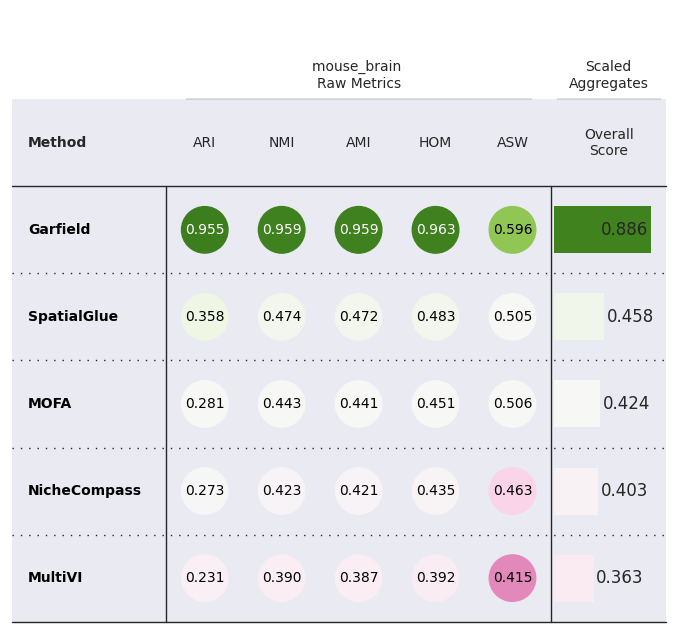

In [12]:
# Plot table
res_dir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/mouse_brain'

plot_simple_metrics_table(
    df=unrolled_df,
    model_col="Method",
    model_col_width=1.6,
    group_col="Dataset",
    metric_cols=metric_cols_single_sample, # metric_cols_single_sample, category_cols_single_sample
    metric_col_weights=metric_col_weights_single_sample, # metric_col_weights_single_sample, category_col_weights_single_sample
    metric_col_titles=[col.replace(" ", "\n") for col in metric_col_titles_single_sample], # category_col_titles_single_sample
    metric_col_width=0.8, # 0.8,
    aggregate_col_width=1.2,
    plot_width=8.5, # 32,
    plot_height=8,
    show=True,
    save_dir=res_dir,
    save_name=f"benchmarking_metrics_spatial_multimodal_renew.pdf")

### 探索单独RNA模态，ATAC模态以及 RNA+ATAC模态对metrics的影响

In [5]:
## load data
res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/mouse_brain'
adata_rna = sc.read_h5ad(f'{res_dir}/adata_garfield_RNA.h5ad')
adata_atac = sc.read_h5ad(f'{res_dir}/adata_garfield_ATAC.h5ad')
adata_concat = sc.read_h5ad(f'{res_dir}/adata_garfield.h5ad')

In [14]:
adata_concat.obsm['garfield_concat'] = adata_concat.obsm['garfield_latent_run1']
adata_concat.obsm['garfield_rna'] = adata_rna.obsm['garfield_latent_run1']
adata_concat.obsm['garfield_atac'] = adata_atac.obsm['garfield_latent_run1']

In [15]:
adata_concat

AnnData object with n_obs × n_vars = 9215 × 103000
    obs: 'rna:RNA_clusters', 'rna:batch', 'rna:ATAC_clusters', 'rna:predicted.celltype', 'rna:n_genes', 'atac:RNA_clusters', 'atac:ATAC_clusters', 'atac:batch', 'atac:n_genes', 'latent_leiden_0.5', 'niche_type', 'niche_type_sub'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'garfield_latent', 'garfield_model_training_duration_run1', 'garfield_model_training_duration_run2', 'garfield_model_training_duration_run3', 'garfield_model_training_duration_run4', 'garfield_model_training_duration_run5', 'garfield_model_training_duration_run6', 'garfield_model_training_duration_run7', 'garfield_model_training_duration_run8', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'niche_type_colors', 'niche_type_sub_colors', 'rna:predicted.celltype_colors', 'umap'
    obsm: 'X_umap', 'garfield_latent', 'garfield_latent_run1', 'garfield_latent_run2', 'garfield_latent_run3', 'garfield_latent_run4

In [16]:
def count_metrics_for_modality(adata, dataset, niche_type_key=None):
    res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/mouse_brain'

    result = pd.DataFrame()
    metrics_list = []
    method_list = ['garfield_concat', 'garfield_rna', 'garfield_atac']

    # 计算不同方法的指标
    for method in method_list:
        # 处理缺失的 niche_type
        if adata.obs[niche_type_key].isna().sum() != 0:
            adata.obs[niche_type_key] = adata.obs[niche_type_key].cat.add_categories(['NaN'])
            adata.obs.loc[adata.obs[niche_type_key].isna(), niche_type_key] = 'NaN'
        # adata.obs['batch'] = ['batch1'] * adata.shape[0]

        print('the length of niche type:', adata.obs[niche_type_key].nunique())
        sc.pp.neighbors(adata, use_rep=method)
        sc.tl.umap(adata)
        # 计算指标
        scib.metrics.cluster_optimal_resolution(adata, cluster_key="cluster", label_key=niche_type_key)

        ari = scib.metrics.ari(adata, cluster_key='cluster', label_key=niche_type_key)
        nmi = scib.metrics.nmi(adata, cluster_key='cluster', label_key=niche_type_key)
        # 计算 AMI
        label = adata.obs[niche_type_key].values
        pred = adata.obs['cluster'].values
        ami = np.round(metrics.adjusted_mutual_info_score(label, pred), 4)
        # 计算 HOM (Homogeneity)
        hom = np.round(metrics.homogeneity_score(label, pred), 4)
        sht = scib.metrics.silhouette(adata, label_key=niche_type_key, embed=method, scale=True) #  metric='euclidean',
        metrics_list.append([ari, nmi, ami, hom, sht, method])

    # 保存结果
    df = pd.DataFrame(metrics_list, columns=['ARI', 'NMI', 'AMI', 'Homogeneity',
                                             'Silhouette', 'method'])
    result = pd.concat([result, df], ignore_index=True)
    result['Dataset'] = dataset
    result.to_csv(f'{res_dir}/{dataset}_metrics_result_modality.csv', index=False)
    print(dataset)

    return adata

In [17]:
count_metrics_for_modality(adata=adata_concat,
                           dataset='mouse_brain',
                           niche_type_key='niche_type_sub')

the length of niche type: 14
resolution: 0.1, nmi: 0.49598330370250804
resolution: 0.2, nmi: 0.5946832521022255
resolution: 0.3, nmi: 0.6033458072934486
resolution: 0.4, nmi: 0.6036098935417316
resolution: 0.5, nmi: 0.605706377475792
resolution: 0.6, nmi: 0.608641406749805
resolution: 0.7, nmi: 0.6073958102302459
resolution: 0.8, nmi: 0.6210613748803139
resolution: 0.9, nmi: 0.6171655660364755
resolution: 1.0, nmi: 0.6200580720915663
resolution: 1.1, nmi: 0.6168045238881387
resolution: 1.2, nmi: 0.6009343029356584
resolution: 1.3, nmi: 0.6023127005052314
resolution: 1.4, nmi: 0.6001776472111459
resolution: 1.5, nmi: 0.5963662975050125
resolution: 1.6, nmi: 0.5927097669056
resolution: 1.7, nmi: 0.5910464154050874
resolution: 1.8, nmi: 0.5849321174600626
resolution: 1.9, nmi: 0.591388243488724
resolution: 2.0, nmi: 0.5896988979780792
optimised clustering against niche_type_sub
optimal cluster resolution: 0.8
optimal score: 0.6210613748803139
the length of niche type: 14
resolution: 0.1, 

AnnData object with n_obs × n_vars = 9215 × 103000
    obs: 'rna:RNA_clusters', 'rna:batch', 'rna:ATAC_clusters', 'rna:predicted.celltype', 'rna:n_genes', 'atac:RNA_clusters', 'atac:ATAC_clusters', 'atac:batch', 'atac:n_genes', 'latent_leiden_0.5', 'niche_type', 'niche_type_sub', 'cluster'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'garfield_latent', 'garfield_model_training_duration_run1', 'garfield_model_training_duration_run2', 'garfield_model_training_duration_run3', 'garfield_model_training_duration_run4', 'garfield_model_training_duration_run5', 'garfield_model_training_duration_run6', 'garfield_model_training_duration_run7', 'garfield_model_training_duration_run8', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'niche_type_colors', 'niche_type_sub_colors', 'rna:predicted.celltype_colors', 'umap', 'neighbors', 'cluster'
    obsm: 'X_umap', 'garfield_latent', 'garfield_latent_run1', 'garfield_latent_run2', 'garfield_

In [18]:
save_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/mouse_brain'

df = pd.read_csv(f'{save_path}/mouse_brain_metrics_result_modality.csv')
df

,ARI,NMI,AMI,Homogeneity,Silhouette,method,Dataset
0,0.503874,0.621061,0.6197,0.6256,0.561479,garfield_concat,mouse_brain
1,0.265388,0.351065,0.3499,0.2882,0.483234,garfield_rna,mouse_brain
2,0.449721,0.558624,0.5569,0.5525,0.536584,garfield_atac,mouse_brain
